In [81]:
# ============================================================
#  Configuration — edit here only
# ============================================================
RESULTS_DIR = "/mnt/d/projects/vllm_hybrid/eval/results"
RUN_NAME    = "20260329_120850"   # timestamp directory name
# ============================================================

import json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
GPU_COLOR    = "#4C72B0"
HYBRID_COLOR = "#DD8452"
PALETTE      = {"GPU-only": GPU_COLOR, "Hybrid": HYBRID_COLOR}

run_dir = Path(RESULTS_DIR) / RUN_NAME

def load_json(name):
    p = run_dir / name
    return json.load(open(p)) if p.exists() else None

def load_csv(name):
    p = run_dir / name
    if not p.exists(): return None
    df = pd.read_csv(p)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

def get_core_cols(df):
    """Dynamically detect core columns from CSV (handles any core count)"""
    if df is None: return []
    return [c for c in df.columns if c.startswith("core") and c.endswith("_util_pct")]

def get_gpu_indices(df):
    """Detect available GPU indices from CSV columns"""
    if df is None: return []
    indices = set()
    for c in df.columns:
        if c.startswith("gpu") and "_util_pct" in c and not c.startswith("gpu_avg"):
            try: indices.add(int(c.replace("gpu","").split("_")[0]))
            except: pass
    return sorted(indices)

gpu_only    = load_json("gpu_only.json")
hybrid      = load_json("hybrid.json")
comparison  = load_json("comparison.json")
system_info = load_json("system_info.json")
g_gpu_csv   = load_csv("gpu_only_monitor_gpu.csv")
g_cpu_csv   = load_csv("gpu_only_monitor_cpu.csv")
h_gpu_csv   = load_csv("hybrid_monitor_gpu.csv")
h_cpu_csv   = load_csv("hybrid_monitor_cpu.csv")

model = (hybrid or gpu_only or {}).get("model_id", "?")
n_cores_g = len(get_core_cols(g_cpu_csv))
n_cores_h = len(get_core_cols(h_cpu_csv))
gpus_g = get_gpu_indices(g_gpu_csv)
gpus_h = get_gpu_indices(h_gpu_csv)
print(f"Run        : {RUN_NAME}")
print(f"Model      : {model}")
print(f"CPU cores  : gpu_only={n_cores_g}, hybrid={n_cores_h}")
print(f"GPU indices: gpu_only={gpus_g}, hybrid={gpus_h}")
print(f"system_info: {'YES' if system_info else 'NO'}")
print(f"Available  : gpu_only={'YES' if gpu_only else 'NO'}  "
      f"hybrid={'YES' if hybrid else 'NO'}  "
      f"comparison={'YES' if comparison else 'NO'}")


Run        : 20260329_120850
Model      : Qwen/Qwen2.5-1.5B
CPU cores  : gpu_only=24, hybrid=24
GPU indices: gpu_only=[0], hybrid=[0]
system_info: YES
Available  : gpu_only=YES  hybrid=YES  comparison=YES


In [82]:
# ============================================================
#  Section 0 ▶ System Information
# ============================================================

if not system_info:
    print("system_info.json not found (older run format)")
else:
    si = system_info

    # ── Hardware ─────────────────────────────────────────────
    cpu  = si.get("cpu", {})
    gpu  = si.get("gpu", {})
    mem  = si.get("memory", {})
    numa = si.get("numa", {})
    sw   = si.get("software", {})
    os_  = si.get("os", {})
    disk = si.get("disk", {})
    kern = si.get("kernel", {})

    hw_rows = [
        ("Hostname",        si.get("hostname", "-")),
        ("OS",              f"{os_.get('distro','-')}  ({os_.get('release','-')})"),
        ("CPU Model",       cpu.get("model_name", "-")),
        ("CPU Topology",    f"{cpu.get('sockets','-')} socket × {cpu.get('cores_per_socket','-')} cores × {cpu.get('threads_per_core','-')} threads  ({cpu.get('total_cpus','-')} logical CPUs)"),
        ("CPU Freq",        f"{cpu.get('cpu_max_mhz','-')} MHz max  /  {cpu.get('cpu_min_mhz','-')} MHz min"),
        ("CPU ISA Flags",   ", ".join(cpu.get("flags", []))),
        ("Cache L1d/L1i/L2/L3", f"{cpu.get('l1d_cache','-')}  /  {cpu.get('l1i_cache','-')}  /  {cpu.get('l2_cache','-')}  /  {cpu.get('l3_cache','-')}"),
        ("NUMA Nodes",      f"{numa.get('num_nodes','-')}  ({', '.join([f"Node {n['node']}: {n['size_mb']/1024:.0f} GB" for n in numa.get('nodes',[])])})"),
        ("RAM Total",       f"{int(mem.get('total','0').replace(' kB','').strip()) / 1024**2:.1f} GB"),
        ("RAM Available",   f"{int(mem.get('available','0').replace(' kB','').strip()) / 1024**2:.1f} GB"),
        ("Swap",            mem.get("swap_total", "-")),
        ("GPU Count",       str(gpu.get("count", "-"))),
    ]
    for dev in gpu.get("devices", []):
        hw_rows += [
            (f"GPU {dev['index']} Name",   dev.get("name", "-")),
            (f"GPU {dev['index']} Memory", f"{int(dev.get('memory_total_mib',0)) / 1024:.1f} GB"),
            (f"GPU {dev['index']} Power Limit", f"{dev.get('power_limit_w','-')} W"),
            (f"GPU {dev['index']} Max SM Clock", f"{dev.get('max_sm_clock_mhz','-')} MHz"),
        ]
    hw_rows += [
        ("CUDA Version",    gpu.get("cuda_version", "-")),
        ("Driver Version",  gpu.get("driver_version", "-")),
        ("Disk",            f"{disk.get('used','-')} used / {disk.get('size','-')} total  ({disk.get('available','-')} free)"),
    ]

    sw_rows = [
        ("Python",          sw.get("python_version", "-")),
        ("PyTorch",         sw.get("torch_version", "-")),
        ("CUDA (torch)",    sw.get("torch_cuda_version", "-")),
        ("cuDNN",           sw.get("cudnn_version", "-")),
        ("vLLM",            sw.get("vllm_version", "-")),
        ("IPEX",            sw.get("ipex_version", "-")),
    ]

    kern_rows = [(k, v) for k, v in kern.items()]

    hw_df   = pd.DataFrame(hw_rows,   columns=["Item", "Value"]).set_index("Item")
    sw_df   = pd.DataFrame(sw_rows,   columns=["Item", "Value"]).set_index("Item")
    kern_df = pd.DataFrame(kern_rows, columns=["Parameter", "Value"]).set_index("Parameter")

    tbl_style = [
        {"selector":"th","props":[("background-color","#2d4a7a"),("color","white"),
                                   ("font-size","12px"),("padding","5px 10px")]},
        {"selector":"tr:nth-child(even)","props":[("background-color","#f5f8ff")]},
        {"selector":"td","props":[("font-size","12px"),("padding","4px 10px")]},
    ]

    print("── Hardware ─────────────────────────────────────────")
    display(hw_df.style.set_table_styles(tbl_style)
            .set_caption("<b>Hardware Information</b>"))

    print("\n── Software ──────────────────────────────────────────")
    display(sw_df.style.set_table_styles(tbl_style)
            .set_caption("<b>Software Versions</b>"))

    print("\n── Kernel Parameters ────────────────────────────────")
    display(kern_df.style.set_table_styles(tbl_style)
            .set_caption("<b>Kernel / OS Parameters</b>"))

    # Eval env config
    eval_env = si.get("eval_env", "")
    if eval_env:
        from IPython.display import HTML, display as ipy_display
        # Parse .env text into sections
        sections = {}
        cur_section = "General"
        for line in eval_env.splitlines():
            stripped = line.strip()
            if not stripped:
                continue
            # Section header: # --- Xxx ---
            if stripped.startswith("# ---") and stripped.endswith("---"):
                cur_section = stripped.strip("# -").strip()
                continue
            # Skip top-level comment block (===)
            if stripped.startswith("#") and "===" in stripped:
                continue
            # Key=Value
            if "=" in stripped and not stripped.startswith("#"):
                key, _, val = stripped.partition("=")
                comment = ""
                if "#" in val:
                    val, _, comment = val.partition("#")
                sections.setdefault(cur_section, []).append(
                    (key.strip(), val.strip(), comment.strip()))
            elif stripped.startswith("#") and stripped.strip("# "):
                # inline comment-only lines (descriptions)
                sections.setdefault(cur_section, []).append(
                    ("", "", stripped.lstrip("# ")))

        # ── Title comment (first === line) ─────────────────
        title_line = next((l.strip("# =").strip() for l in eval_env.splitlines()
                           if "===" not in l and l.strip().startswith("#")
                           and l.strip().lstrip("# ")), "Eval Environment Config")

        html_parts = [
            '<div style="margin:12px 0">',
            f'<div style="background:#2d4a7a;color:white;padding:8px 14px;'
            f'border-radius:6px 6px 0 0;font-weight:bold;font-size:14px">'
            f'Eval Environment Config &nbsp;<span style="font-weight:normal;'
            f'font-size:12px;opacity:.8">{title_line}</span></div>',
            '<table style="border-collapse:collapse;width:100%;font-size:12px;'
            'font-family:monospace;border:1px solid #cdd6e5">',
        ]

        SECTION_COLORS = [
            "#e8f0fe","#fff3e0","#e8f5e9","#fce4ec",
            "#ede7f6","#e0f7fa","#fff9c4","#f3e5f5",
        ]
        row_idx = 0
        for sec_i, (sec, rows) in enumerate(sections.items()):
            sec_color = SECTION_COLORS[sec_i % len(SECTION_COLORS)]
            # Section header row
            html_parts.append(
                f'<tr><td colspan="3" style="background:{sec_color};'
                f'font-weight:bold;padding:5px 12px;color:#34495e;'
                f'border-top:2px solid #aec0d9;letter-spacing:.5px">'
                f'{sec}</td></tr>')
            for key, val, cmt in rows:
                if not key:
                    # comment-only line
                    html_parts.append(
                        f'<tr style="background:#fafafa"><td colspan="3" '
                        f'style="padding:2px 12px 2px 24px;color:#888;font-style:italic">'
                        f'# {cmt}</td></tr>')
                    continue
                bg = "#ffffff" if row_idx % 2 == 0 else "#f7faff"
                cmt_html = (f'<span style="color:#aaa;padding-left:10px"># {cmt}</span>'
                            if cmt else "")
                html_parts.append(
                    f'<tr style="background:{bg}">'
                    f'<td style="padding:4px 12px 4px 24px;color:#1a5276;'
                    f'font-weight:600;white-space:nowrap;width:38%">{key}</td>'
                    f'<td style="padding:4px 8px;color:#117a65;width:2%">=</td>'
                    f'<td style="padding:4px 8px;color:#2c3e50">'
                    f'{val}{cmt_html}</td></tr>')
                row_idx += 1

        html_parts += ['</table></div>']
        ipy_display(HTML("\n".join(html_parts)))


── Hardware ─────────────────────────────────────────


,Value
Item,
Hostname,mystousUbuntu
OS,Ubuntu 22.04.5 LTS (6.8.0-90-generic)
CPU Model,12th Gen Intel(R) Core(TM) i9-12900KF
CPU Topology,1 socket × 16 cores × 2 threads (24 logical CPUs)
CPU Freq,5200.0000 MHz max / 800.0000 MHz min
CPU ISA Flags,"avx, avx2, sse4_1, sse4_2, fma"
Cache L1d/L1i/L2/L3,640 KiB (16 instances) / 768 KiB (16 instances) / 14 MiB (10 instances) / 30 MiB (1 instance)
NUMA Nodes,1 (Node 0: 63 GB)
RAM Total,62.7 GB



── Software ──────────────────────────────────────────


,Value
Item,
Python,3.12.13
PyTorch,2.7.1+cu128
CUDA (torch),12.8
cuDNN,90701
vLLM,0.1.dev8402+gdac8e0e5d
IPEX,2.7.0+cpu



── Kernel Parameters ────────────────────────────────


,Value
Parameter,
vm.swappiness,60
vm.nr_hugepages,0
vm.overcommit_memory,0
kernel.numa_balancing,0


In [83]:
# ============================================================
#  1. Benchmark Metadata & Config Parameters
# ============================================================

meta_keys = [
    ('date',                 'Benchmark Date'),
    ('backend',              'Backend'),
    ('model_id',             'Model ID'),
    ('tokenizer_id',         'Tokenizer ID'),
    ('num_prompts',          'Num Prompts'),
    ('request_rate',         'Request Rate'),
    ('burstiness',           'Burstiness'),
    ('max_concurrency',      'Max Concurrency'),
    ('completed',            'Completed Requests'),
    ('total_input_tokens',   'Total Input Tokens'),
    ('total_output_tokens',  'Total Output Tokens'),
    ('duration',             'Duration (s)'),
]

rows = []
for key, label in meta_keys:
    g_val = (gpu_only or {}).get(key, '-')
    h_val = (hybrid   or {}).get(key, '-')
    rows.append({'Parameter': label, 'GPU-only': g_val, 'Hybrid': h_val})

meta_df = pd.DataFrame(rows).set_index('Parameter')

def style_meta(df):
    return df.style \
        .set_properties(**{'text-align': 'left', 'font-size': '13px',
                           'border-color': '#e0e0e0'}) \
        .set_table_styles([
            {'selector': 'th',
             'props': [('background-color', '#2d4a7a'), ('color', 'white'),
                       ('font-size', '13px'), ('padding', '6px 12px')]},
            {'selector': 'tr:nth-child(even)',
             'props': [('background-color', '#f5f8ff')]},
            {'selector': 'tr:hover',
             'props': [('background-color', '#dce8ff')]},
        ]) \
        .set_caption('<b style="font-size:15px">Benchmark Metadata & Configuration</b>')

style_meta(meta_df)

,GPU-only,Hybrid
Parameter,,
Benchmark Date,20260329-031107,20260329-031345
Backend,vllm,vllm
Model ID,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-1.5B
Tokenizer ID,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-1.5B
Num Prompts,2000,2000
Request Rate,inf,inf
Burstiness,1.000000,1.000000
Max Concurrency,None,None
Completed Requests,2000,2000


In [84]:
# ============================================================
#  2. Full Performance Metrics Table
# ============================================================

perf_keys = [
    ('request_throughput',     'Request Throughput (req/s)',     'higher'),
    ('request_goodput',        'Request Goodput (req/s)',        'higher'),
    ('output_throughput',      'Output Throughput (tok/s)',      'higher'),
    ('total_token_throughput', 'Total Token Throughput (tok/s)', 'higher'),
    ('duration',               'Duration (s)',                   'lower'),
    ('mean_ttft_ms',           'Mean TTFT (ms)',                 'lower'),
    ('median_ttft_ms',         'Median TTFT (ms)',               'lower'),
    ('std_ttft_ms',            'Std TTFT (ms)',                  'lower'),
    ('p99_ttft_ms',            'P99 TTFT (ms)',                  'lower'),
    ('mean_tpot_ms',           'Mean TPOT (ms)',                 'lower'),
    ('median_tpot_ms',         'Median TPOT (ms)',               'lower'),
    ('std_tpot_ms',            'Std TPOT (ms)',                  'lower'),
    ('p99_tpot_ms',            'P99 TPOT (ms)',                  'lower'),
    ('mean_itl_ms',            'Mean ITL (ms)',                  'lower'),
    ('median_itl_ms',          'Median ITL (ms)',                'lower'),
    ('std_itl_ms',             'Std ITL (ms)',                   'lower'),
    ('p99_itl_ms',             'P99 ITL (ms)',                   'lower'),
]

# diff data lives under comparison['comparison'], not the top level
cmp_sub = (comparison or {}).get('comparison', {})

rows = []
for key, label, better in perf_keys:
    g_val = (gpu_only or {}).get(key)
    h_val = (hybrid   or {}).get(key)
    cmp_entry = cmp_sub.get(key, {})
    diff = cmp_entry.get('diff_pct', np.nan) if isinstance(cmp_entry, dict) else np.nan
    if not np.isnan(diff) and g_val is not None and h_val is not None:
        win = (diff > 0 and better == 'higher') or (diff < 0 and better == 'lower')
        if abs(diff) <= 0.5:
            result = 'Tie'
        elif win:
            result = 'Hybrid'
        else:
            result = 'GPU-only'
    else:
        result = '-'
    rows.append({'Metric': label, 'Dir': '↑' if better == 'higher' else '↓',
                 'GPU-only': g_val, 'Hybrid': h_val, 'Diff (%)': diff, 'Winner': result})

perf_df = pd.DataFrame(rows).set_index('Metric')

def color_diff(val):
    if pd.isna(val): return ''
    if val < -0.5:  return 'color: #1a7f3c; font-weight: bold; background-color: #eafaf1'
    if val >  0.5:  return 'color: #c0392b; font-weight: bold; background-color: #fdedec'
    return 'color: #888'

perf_df.style \
    .format({'GPU-only': '{:.3f}', 'Hybrid': '{:.3f}', 'Diff (%)': '{:+.2f}'}, na_rep='-') \
    .applymap(color_diff, subset=['Diff (%)']) \
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#2d4a7a'), ('color', 'white'),
                   ('font-size', '12px'), ('padding', '5px 10px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f9f9f9')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#eef3fb')]},
    ]) \
    .set_caption('<b style="font-size:15px">Full Performance Metrics</b>')


,Dir,GPU-only,Hybrid,Diff (%),Winner
Metric,,,,,
Request Throughput (req/s),↑,19.492,18.240,-6.42,GPU-only
Request Goodput (req/s),↑,-,-,-,-
Output Throughput (tok/s),↑,9808.183,9164.768,-6.56,GPU-only
Total Token Throughput (tok/s),↑,12297.393,11494.146,-6.53,GPU-only
Duration (s),↓,102.608,109.648,+6.86,GPU-only
Mean TTFT (ms),↓,45270.619,49839.530,+10.09,GPU-only
Median TTFT (ms),↓,41415.247,46760.587,+12.91,GPU-only
Std TTFT (ms),↓,28983.947,31886.459,-,-
P99 TTFT (ms),↓,93623.845,101273.768,+8.17,GPU-only


In [85]:
# ============================================================
#  3. Speedup & Overall Comparison Summary
# ============================================================

if not comparison:
    print('comparison.json not found')
else:
    cmp_sub = comparison.get('comparison', {})

    req_speedup = cmp_sub.get('request_throughput_speedup', np.nan)
    out_speedup = cmp_sub.get('output_tok_speedup', np.nan)
    ttft_gain   = cmp_sub.get('ttft_gain_pct', np.nan)

    print(f'  Request Throughput Speedup : {req_speedup:.4f}x')
    print(f'  Output Token Speedup       : {out_speedup:.4f}x')
    print(f'  TTFT Gain (Hybrid vs GPU)  : {ttft_gain:+.2f}%  '
          f"({'worse' if ttft_gain > 0 else 'better'})")

    cmp_rows = []
    for key, val in cmp_sub.items():
        if isinstance(val, dict) and 'diff_pct' in val:
            cmp_rows.append({'Key': key,
                             'Direction': val.get('direction', '-'),
                             'Diff (%)': val['diff_pct']})

    if cmp_rows:
        cmp_df = pd.DataFrame(cmp_rows).set_index('Key')

        def bar_color(val):
            if pd.isna(val): return ''
            if val < -0.5:  return 'color:#1a7f3c; font-weight:bold; background:#eafaf1'
            if val >  0.5:  return 'color:#c0392b; font-weight:bold; background:#fdedec'
            return 'color:#888'

        display(cmp_df.style
            .format({'Diff (%)': '{:+.2f}'})
            .applymap(bar_color, subset=['Diff (%)'])
            .bar(subset=['Diff (%)'], align='zero',
                 color=['#aed6b8', '#f5b7b1'], vmin=-100, vmax=100)
            .set_table_styles([{
                'selector': 'th',
                'props': [('background-color','#2d4a7a'),('color','white'),
                          ('font-size','12px'),('padding','5px 10px')],
            }])
            .set_caption('<b style="font-size:15px">All Diff (%) — Hybrid vs GPU-only</b>'))


  Request Throughput Speedup : 0.9358x
  Output Token Speedup       : 0.9344x
  TTFT Gain (Hybrid vs GPU)  : -10.09%  (better)


,Direction,Diff (%)
Key,,
request_throughput,higher_better,-6.42
output_throughput,higher_better,-6.56
total_token_throughput,higher_better,-6.53
duration,lower_better,+6.86
mean_ttft_ms,lower_better,+10.09
median_ttft_ms,lower_better,+12.91
p99_ttft_ms,lower_better,+8.17
mean_tpot_ms,lower_better,+8.97
median_tpot_ms,lower_better,+5.85


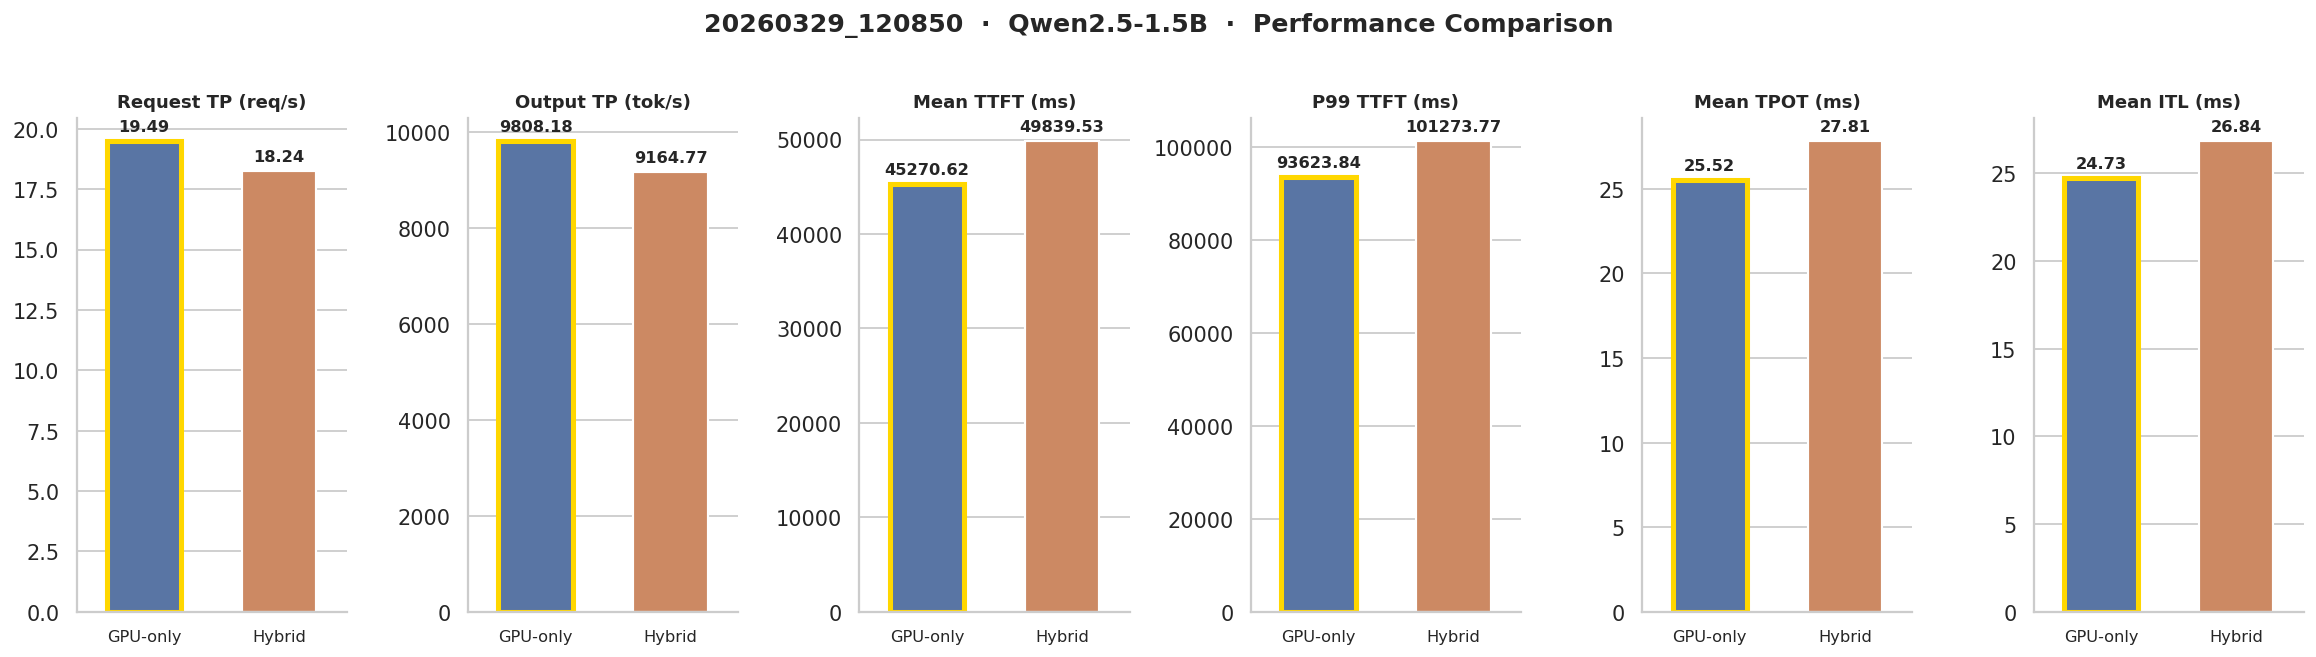

In [86]:
# ============================================================
#  4. Throughput & Latency Bar Charts
# ============================================================

plot_items = [
    ('request_throughput', 'Request TP\n(req/s)',   'higher'),
    ('output_throughput',  'Output TP\n(tok/s)',    'higher'),
    ('mean_ttft_ms',       'Mean TTFT\n(ms)',       'lower'),
    ('p99_ttft_ms',        'P99 TTFT\n(ms)',        'lower'),
    ('mean_tpot_ms',       'Mean TPOT\n(ms)',       'lower'),
    ('mean_itl_ms',        'Mean ITL\n(ms)',        'lower'),
]

# build tidy DataFrame
bar_rows = []
for key, label, better in plot_items:
    g_val = (gpu_only or {}).get(key, 0) or 0
    h_val = (hybrid   or {}).get(key, 0) or 0
    for mode, val in [('GPU-only', g_val), ('Hybrid', h_val)]:
        bar_rows.append({'Metric': label, 'Mode': mode, 'Value': val,
                         'Better': better})
bar_df = pd.DataFrame(bar_rows)

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle(
    f"{RUN_NAME}  ·  {model.split('/')[-1]}  ·  Performance Comparison",
    fontsize=14, fontweight='bold', y=1.01)

for ax, (key, label, better) in zip(axes, plot_items):
    sub = bar_df[bar_df['Metric'] == label]
    g_val = sub[sub['Mode']=='GPU-only']['Value'].values[0]
    h_val = sub[sub['Mode']=='Hybrid']['Value'].values[0]

    g = sns.barplot(data=sub, x='Mode', y='Value', palette=PALETTE,
                    order=['GPU-only','Hybrid'], ax=ax,
                    edgecolor='white', linewidth=1.2, width=0.55)

    # winner highlight
    win_mode = ('GPU-only' if g_val > h_val else 'Hybrid') if better=='higher' \
               else ('GPU-only' if g_val < h_val else 'Hybrid')
    for patch, mode in zip(ax.patches, ['GPU-only','Hybrid']):
        if mode == win_mode:
            patch.set_edgecolor('#FFD700'); patch.set_linewidth(2.8)

    # value labels
    for patch in ax.patches:
        v = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2,
                v + max(g_val, h_val)*0.015,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(label.replace('\n',' '), fontsize=10, fontweight='semibold', pad=6)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9)

sns.despine()
plt.tight_layout()
plt.show()

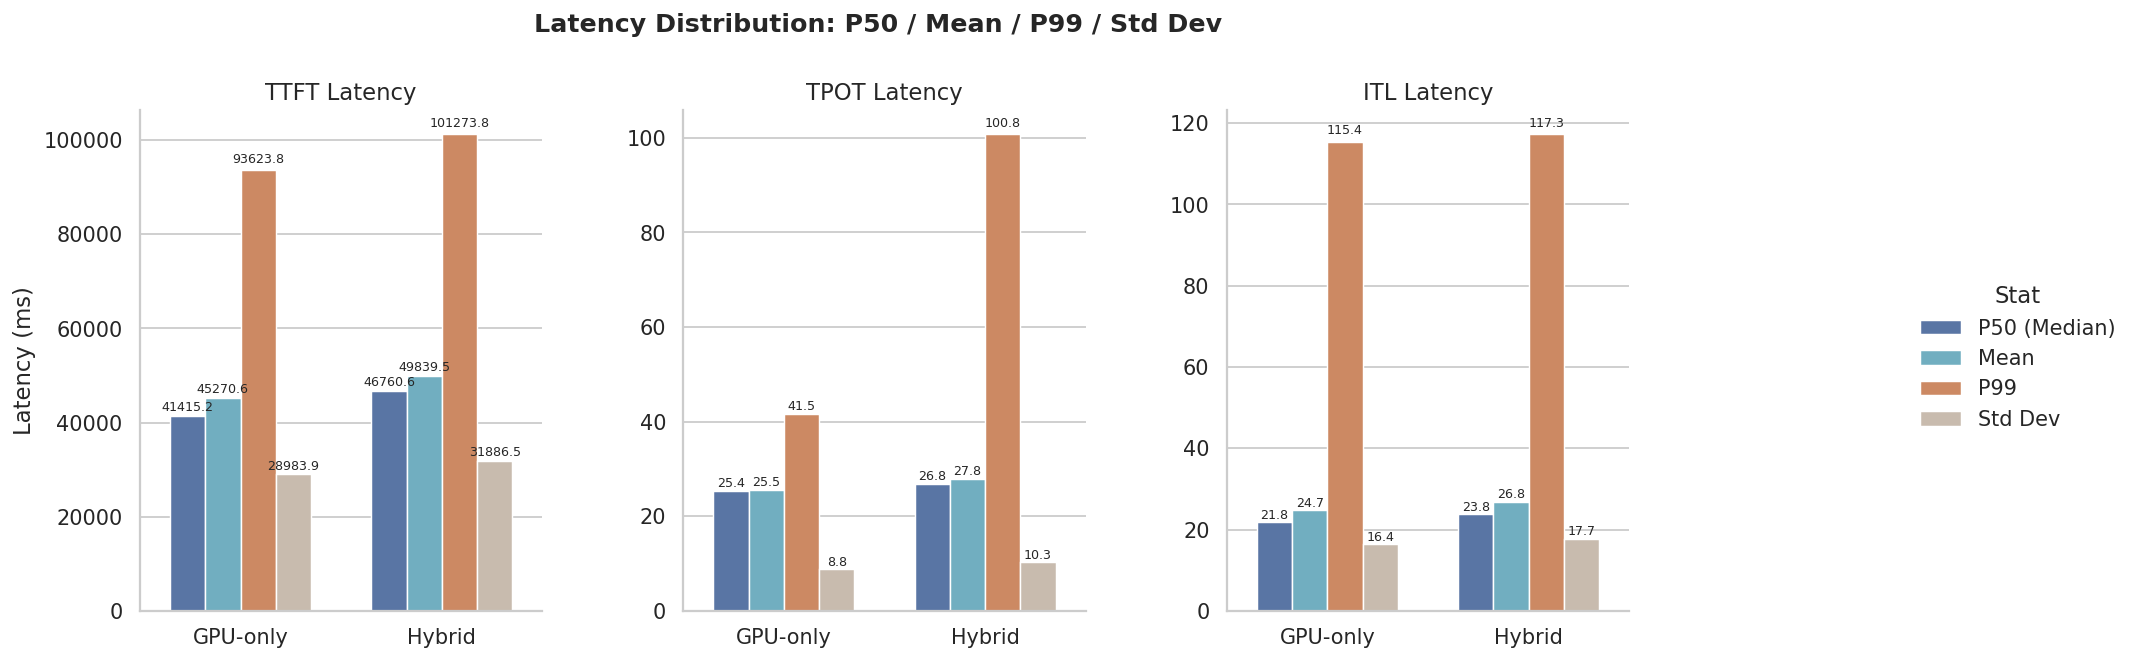

In [87]:
# ============================================================
#  5. Latency Distribution: P50 / P99 / Std
# ============================================================

lat_groups = [
    ('TTFT', 'median_ttft_ms', 'mean_ttft_ms', 'p99_ttft_ms', 'std_ttft_ms'),
    ('TPOT', 'median_tpot_ms', 'mean_tpot_ms', 'p99_tpot_ms', 'std_tpot_ms'),
    ('ITL',  'median_itl_ms',  'mean_itl_ms',  'p99_itl_ms',  'std_itl_ms'),
]

lat_rows = []
for name, p50k, meank, p99k, stdk in lat_groups:
    for mode, src in [('GPU-only', gpu_only), ('Hybrid', hybrid)]:
        if src is None: continue
        lat_rows += [
            {'Metric': name, 'Mode': mode, 'Stat': 'P50 (Median)', 'ms': src.get(p50k, 0) or 0},
            {'Metric': name, 'Mode': mode, 'Stat': 'Mean',         'ms': src.get(meank, 0) or 0},
            {'Metric': name, 'Mode': mode, 'Stat': 'P99',          'ms': src.get(p99k, 0) or 0},
            {'Metric': name, 'Mode': mode, 'Stat': 'Std Dev',      'ms': src.get(stdk, 0) or 0},
        ]
lat_df = pd.DataFrame(lat_rows)

stat_palette = {'P50 (Median)': '#4C72B0', 'Mean': '#64B5CD',
                'P99': '#DD8452',           'Std Dev': '#CCBBAA'}

g = sns.FacetGrid(lat_df, col='Metric', height=5, aspect=0.9,
                  sharey=False, gridspec_kws={'wspace': 0.35})

def draw_grouped(data, **kw):
    ax = plt.gca()
    sns.barplot(data=data, x='Mode', y='ms', hue='Stat',
                palette=stat_palette, order=['GPU-only','Hybrid'],
                hue_order=['P50 (Median)','Mean','P99','Std Dev'],
                edgecolor='white', linewidth=0.8, ax=ax, width=0.7)
    for patch in ax.patches:
        v = patch.get_height()
        if v > 0:
            ax.text(patch.get_x() + patch.get_width()/2,
                    v * 1.01, f'{v:.1f}',
                    ha='center', va='bottom', fontsize=7)

g.map_dataframe(draw_grouped)
g.set_axis_labels('', 'Latency (ms)')
g.set_titles(col_template='{col_name} Latency')
g.add_legend(title='Stat', bbox_to_anchor=(1.02, 0.5), loc='center left')
g.figure.suptitle('Latency Distribution: P50 / Mean / P99 / Std Dev',
                   fontsize=14, fontweight='bold', y=1.03)
sns.despine()
plt.show()

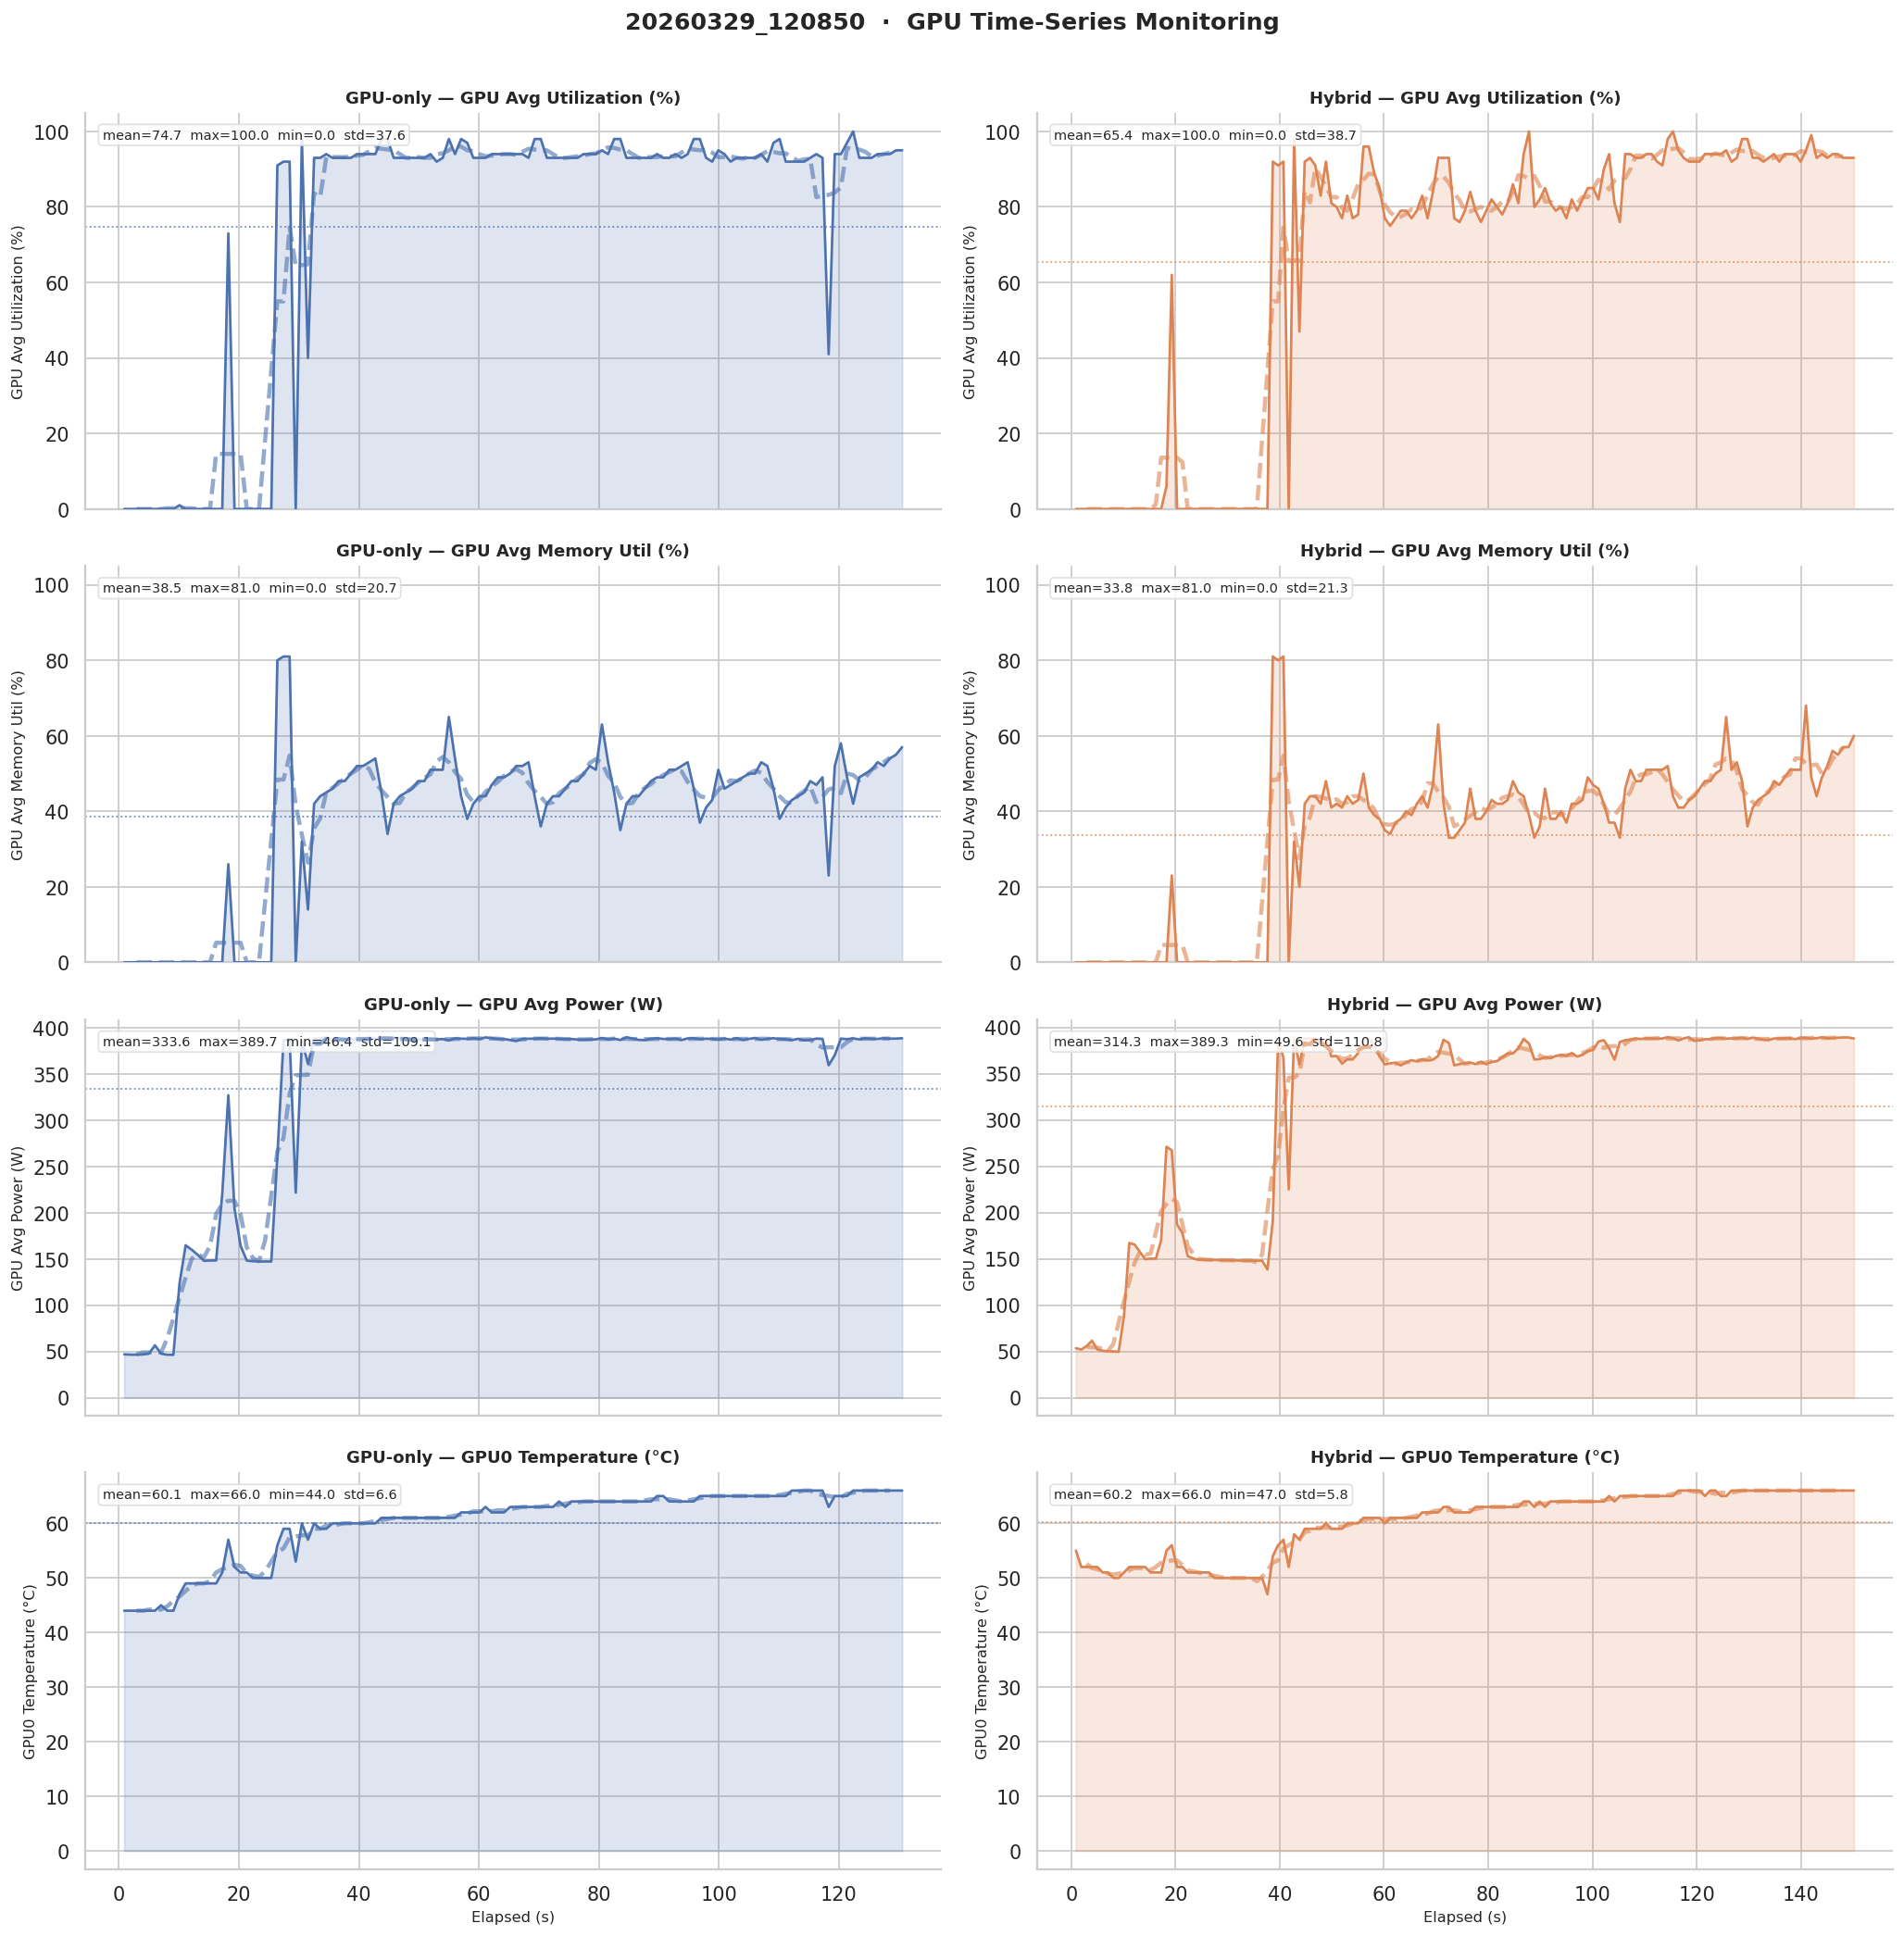

In [88]:
# ============================================================
#  6. GPU Time-Series: Utilization / Memory / Power / Temp
# ============================================================

# ── Aggregate metrics (always present) ───────────────────────
agg_series = [
    ('gpu_avg_util_pct',     'GPU Avg Utilization (%)',  (0, 105)),
    ('gpu_avg_mem_util_pct', 'GPU Avg Memory Util (%)',  (0, 105)),
    ('gpu_avg_power_w',      'GPU Avg Power (W)',        (None, None)),
]

# ── Per-GPU metrics per detected GPU index ────────────────────
def build_per_gpu_series(df_g, df_h):
    """Return list of (col, ylabel, ylim) for per-GPU temp rows."""
    all_indices = sorted(set(get_gpu_indices(df_g)) | set(get_gpu_indices(df_h)))
    return [
        (f'gpu{i}_temp_c', f'GPU{i} Temperature (°C)', (None, None))
        for i in all_indices
    ]

per_gpu_series = build_per_gpu_series(g_gpu_csv, h_gpu_csv)
all_series = agg_series + per_gpu_series
n_rows = len(all_series)

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows), sharex='col')
if n_rows == 1:
    axes = [axes]   # ensure 2-D indexing
fig.suptitle(f'{RUN_NAME}  ·  GPU Time-Series Monitoring',
             fontsize=14, fontweight='bold', y=1.005)

for col, (df, color, label) in enumerate([
    (g_gpu_csv, GPU_COLOR,    'GPU-only'),
    (h_gpu_csv, HYBRID_COLOR, 'Hybrid'),
]):
    for row, (cname, ylabel, ylim) in enumerate(all_series):
        ax = axes[row][col]
        if df is None or cname not in df.columns:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='#aaa')
            ax.set_title(f'{label} — {ylabel}', fontsize=10)
            continue
        t = df['elapsed_s']
        v_series = df[cname].dropna()

        ax.plot(t, df[cname], color=color, linewidth=1.5, zorder=3)
        ax.fill_between(t, df[cname], alpha=0.18, color=color, zorder=2)

        # moving average
        roll = df[cname].rolling(5, center=True).mean()
        ax.plot(t, roll, color=color, linewidth=2.5, alpha=0.6,
                linestyle='--', zorder=4, label='MA-5')

        # mean line
        ax.axhline(v_series.mean(), color=color, linewidth=1,
                   linestyle=':', alpha=0.8)

        if ylim[0] is not None: ax.set_ylim(*ylim)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{label} — {ylabel}', fontsize=10, fontweight='semibold')
        if row == len(all_series) - 1:
            ax.set_xlabel('Elapsed (s)', fontsize=9)

        stats_txt = (f'mean={v_series.mean():.1f}  '
                     f'max={v_series.max():.1f}  '
                     f'min={v_series.min():.1f}  '
                     f'std={v_series.std():.1f}')
        ax.text(0.02, 0.96, stats_txt, transform=ax.transAxes,
                va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#ddd', alpha=0.85))

sns.despine()
plt.tight_layout()
plt.show()


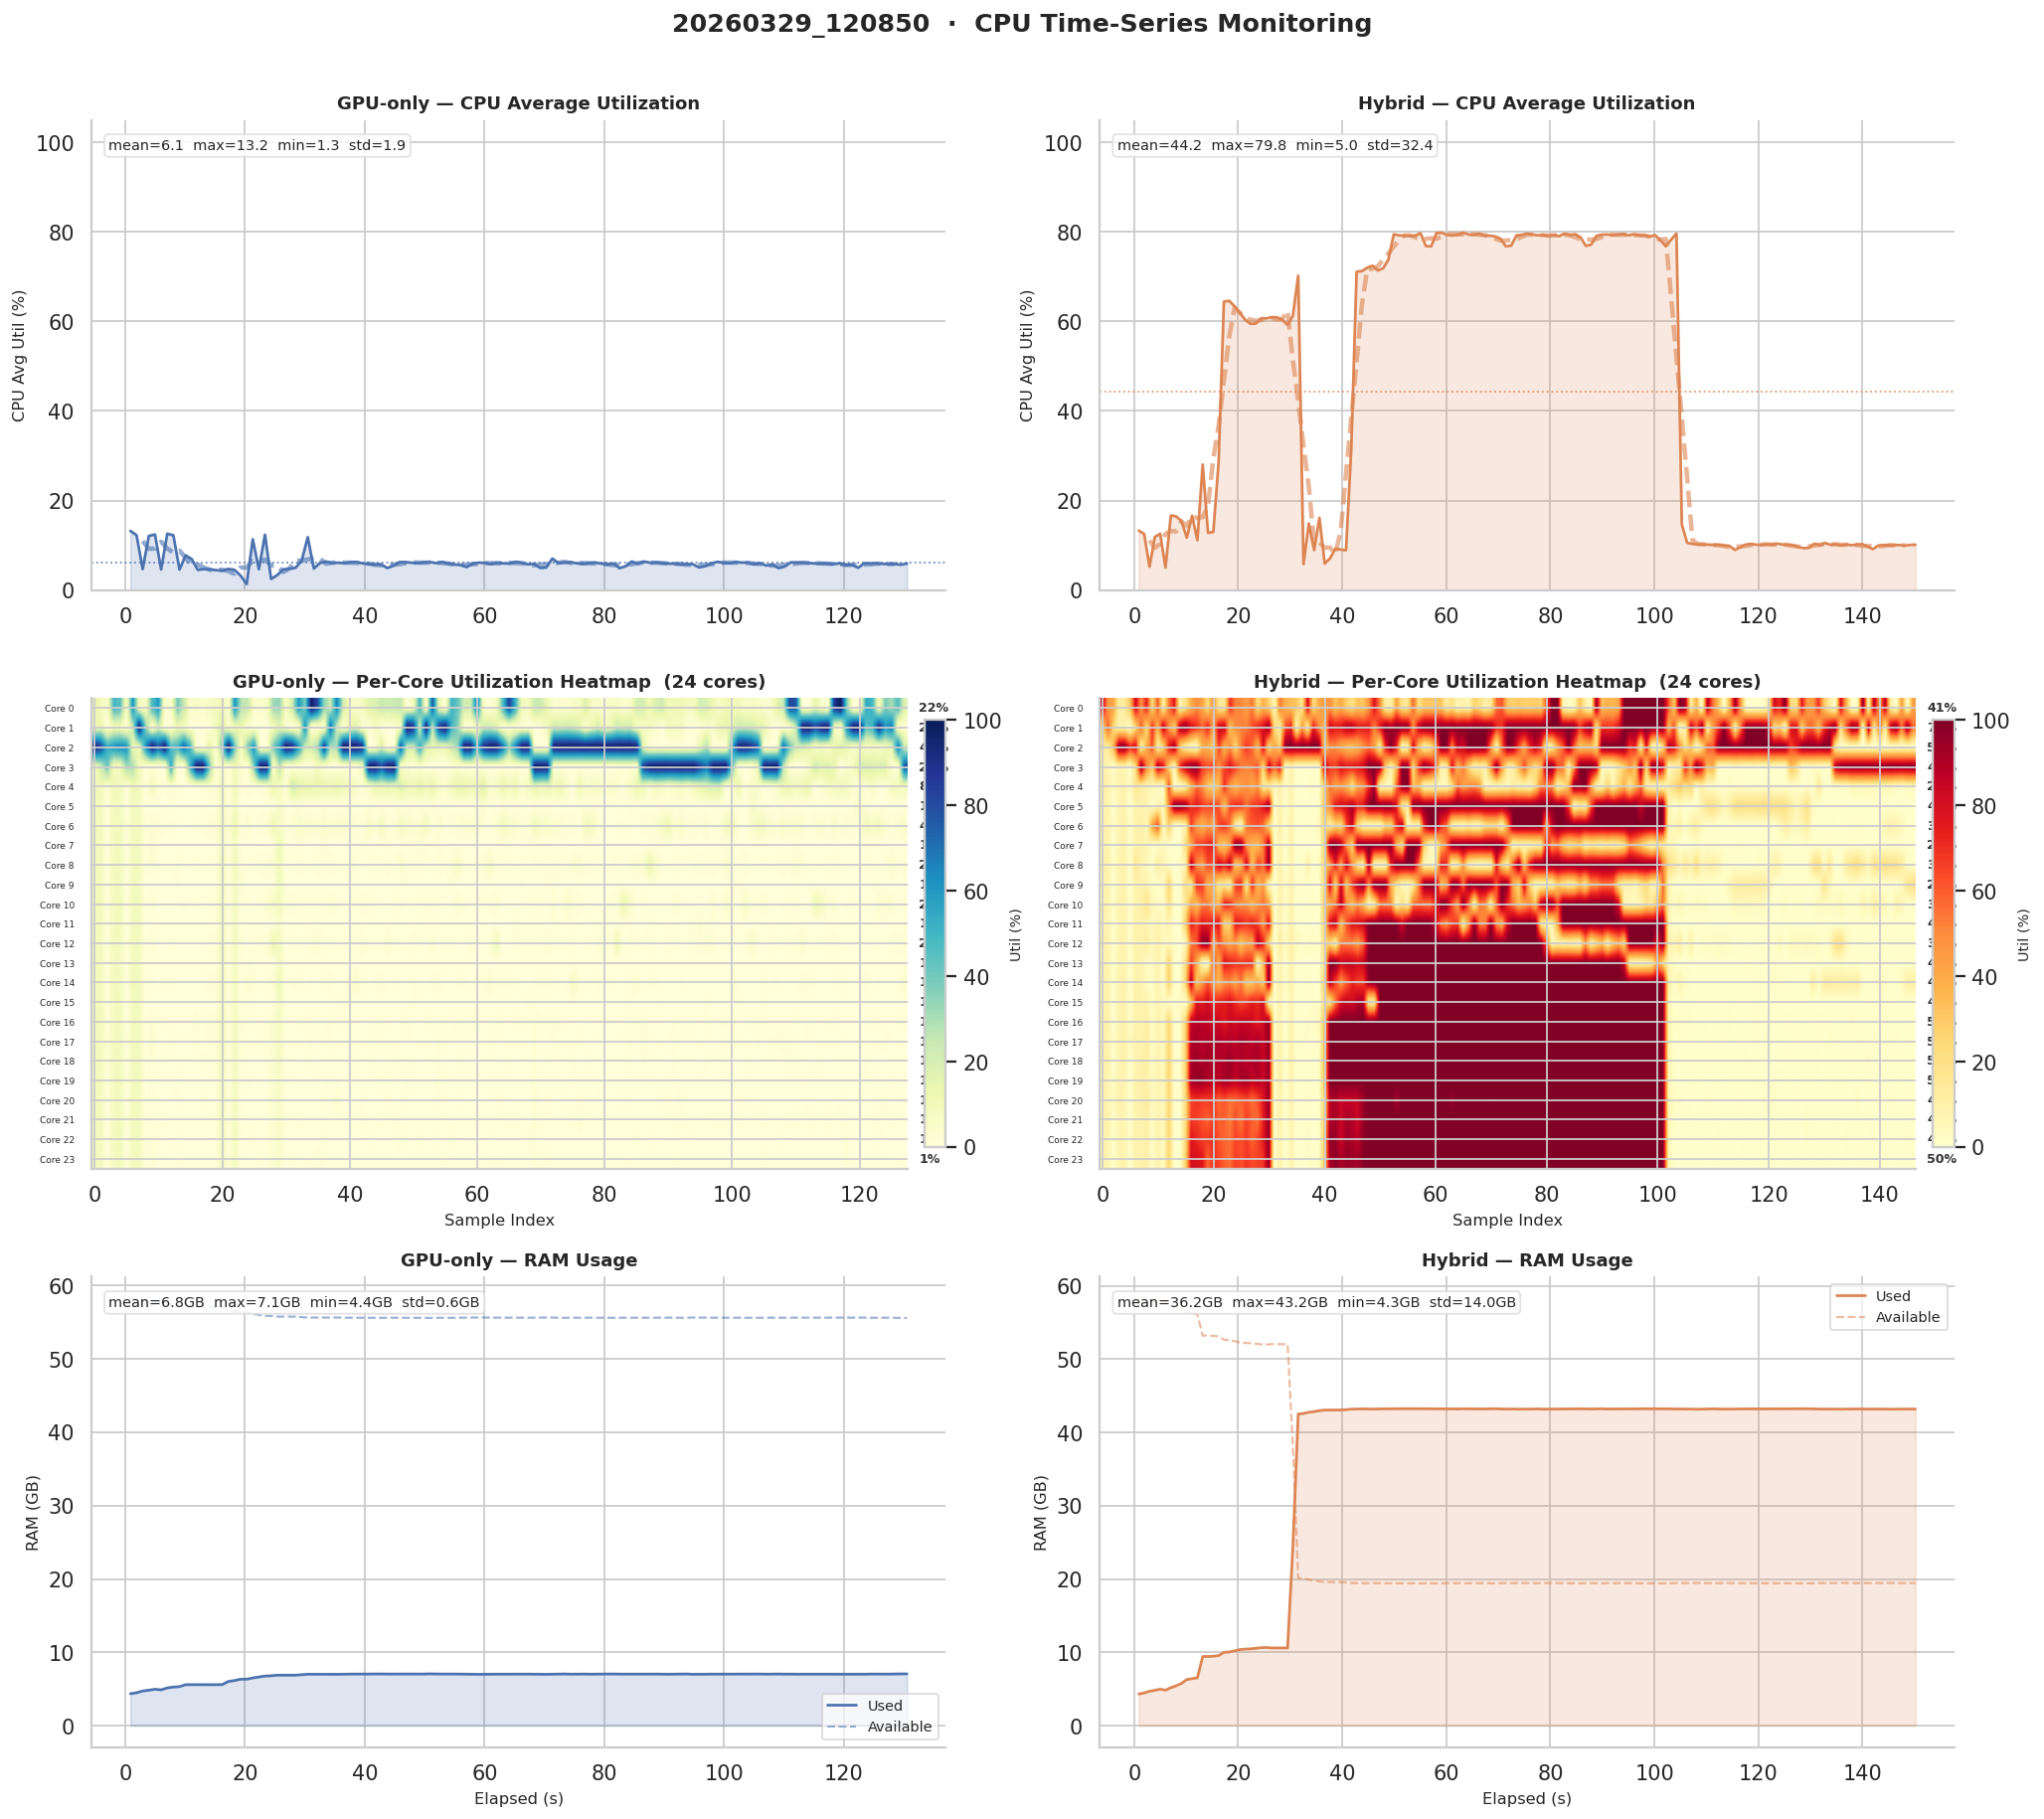

In [89]:
# ============================================================
#  7. CPU Time-Series: Avg Util / Per-Core Heatmap / RAM
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(f'{RUN_NAME}  ·  CPU Time-Series Monitoring',
             fontsize=14, fontweight='bold', y=1.005)

for col, (df, color, label) in enumerate([
    (g_cpu_csv, GPU_COLOR,    'GPU-only'),
    (h_cpu_csv, HYBRID_COLOR, 'Hybrid'),
]):
    if df is None:
        for ax in axes[:, col]:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='#aaa')
        continue

    t  = df['elapsed_s']
    cc = get_core_cols(df)   # dynamic: detects actual core count

    # ── Row 0: CPU avg utilization ────────────────────────────
    ax = axes[0][col]
    v  = df['cpu_avg_util_pct']
    ax.plot(t, v, color=color, linewidth=1.5, zorder=3)
    ax.fill_between(t, v, alpha=0.18, color=color, zorder=2)
    ax.plot(t, v.rolling(5, center=True).mean(),
            color=color, linewidth=2.5, linestyle='--', alpha=0.6, zorder=4)
    ax.axhline(v.mean(), color=color, linewidth=1, linestyle=':', alpha=0.8)
    ax.set_ylim(0, 105)
    ax.set_ylabel('CPU Avg Util (%)', fontsize=9)
    ax.set_title(f'{label} — CPU Average Utilization',
                 fontsize=10, fontweight='semibold')
    vs = v.dropna()
    ax.text(0.02, 0.96,
            f'mean={vs.mean():.1f}  max={vs.max():.1f}  min={vs.min():.1f}  std={vs.std():.1f}',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#ddd', alpha=0.85))

    # ── Row 1: per-core heatmap ───────────────────────────────
    ax = axes[1][col]
    if cc:
        cmap = 'YlOrRd' if label == 'Hybrid' else 'YlGnBu'
        im = ax.imshow(df[cc].T.values, aspect='auto', cmap=cmap,
                       vmin=0, vmax=100, interpolation='bilinear')
        ax.set_yticks(range(len(cc)))
        ax.set_yticklabels(
            [c.replace('_util_pct', '').replace('core', 'Core ') for c in cc],
            fontsize=max(4, 8 - len(cc)//8))
        ax.set_xlabel('Sample Index', fontsize=9)
        ax.set_title(f'{label} — Per-Core Utilization Heatmap  ({len(cc)} cores)',
                     fontsize=10, fontweight='semibold')
        cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
        cb.set_label('Util (%)', fontsize=8)
        # mean % annotations on right
        for i, mv in enumerate(df[cc].mean()):
            ax.text(df[cc].shape[0] * 1.01, i, f'{mv:.0f}%',
                    va='center', fontsize=7,
                    color='#333', fontweight='bold')

    # ── Row 2: RAM usage ─────────────────────────────────────
    ax = axes[2][col]
    if 'cpu_mem_used_mb' in df.columns:
        used_gb  = df['cpu_mem_used_mb'] / 1024
        ax.plot(t, used_gb, color=color, linewidth=1.5, label='Used', zorder=3)
        ax.fill_between(t, used_gb, alpha=0.18, color=color, zorder=2)
    if 'cpu_mem_avail_mb' in df.columns:
        avail_gb = df['cpu_mem_avail_mb'] / 1024
        ax.plot(t, avail_gb, color=color, linewidth=1.2,
                linestyle='--', alpha=0.55, label='Available', zorder=3)
    ax.set_ylabel('RAM (GB)', fontsize=9)
    ax.set_title(f'{label} — RAM Usage', fontsize=10, fontweight='semibold')
    ax.set_xlabel('Elapsed (s)', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    if 'cpu_mem_used_mb' in df.columns:
        m = used_gb.dropna()
        ax.text(0.02, 0.96,
                f'mean={m.mean():.1f}GB  max={m.max():.1f}GB  '
                f'min={m.min():.1f}GB  std={m.std():.1f}GB',
                transform=ax.transAxes, va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='#ddd', alpha=0.85))

sns.despine()
plt.tight_layout()
plt.show()

In [90]:
# ============================================================
#  8. Resource Utilization Stats (from comparison.json)
# ============================================================

if not comparison:
    print('comparison.json not found')
else:
    gu = comparison.get('gpu_utilization', {})
    cu = comparison.get('cpu_utilization', {})

    # ── GPU stats table ───────────────────────────────────────
    gpu_stat_keys = [
        ('gpu0_util_pct',       'GPU0 Util (%)'),
        ('gpu_avg_util_pct',    'GPU Avg Util (%)'),
        ('gpu0_mem_util_pct',   'GPU0 Mem Util (%)'),
        ('gpu_avg_mem_util_pct','GPU Avg Mem Util (%)'),
        ('gpu0_power_w',        'GPU0 Power (W)'),
        ('gpu_avg_power_w',     'GPU Avg Power (W)'),
    ]
    gpu_rows = []
    for mode, label in [('gpu_only','GPU-only'), ('hybrid','Hybrid')]:
        md  = gu.get(mode, {})
        row = {'Mode': label,
               'Samples':     md.get('sample_count', '-'),
               'Duration (s)':md.get('duration_s', '-')}
        for key, col_label in gpu_stat_keys:
            stat = md.get(key, {})
            row[f'{col_label} mean'] = stat.get('mean', np.nan)
            row[f'{col_label} max']  = stat.get('max',  np.nan)
            row[f'{col_label} min']  = stat.get('min',  np.nan)
        gpu_rows.append(row)

    display(pd.DataFrame(gpu_rows).set_index('Mode').T
        .style.format('{:.2f}', na_rep='-')
        .background_gradient(cmap='Blues', axis=1)
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','12px'),('padding','5px 10px')]}])
        .set_caption('<b style="font-size:14px">GPU Utilization Statistics</b>'))

    # ── CPU per-core stats ────────────────────────────────────
    all_core_keys = [k for k in cu.get('gpu_only', {}).keys() if k.startswith('core')]
    cpu_rows = []
    for key in all_core_keys + ['cpu_avg_util_pct']:
        row = {'Core': key.replace('_util_pct','').replace('core','Core ')}
        for mode, label in [('gpu_only','GPU-only'), ('hybrid','Hybrid')]:
            stat = cu.get(mode, {}).get(key, {})
            row[f'{label} mean'] = stat.get('mean', np.nan)
            row[f'{label} max']  = stat.get('max',  np.nan)
            row[f'{label} min']  = stat.get('min',  np.nan)
        cpu_rows.append(row)

    cpu_stat_df = pd.DataFrame(cpu_rows).set_index('Core')
    display(cpu_stat_df.style
        .format('{:.2f}', na_rep='-')
        .background_gradient(cmap='Oranges', subset=['Hybrid mean'], vmin=0, vmax=100)
        .background_gradient(cmap='Blues',   subset=['GPU-only mean'], vmin=0, vmax=100)
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','12px'),('padding','5px 10px')]},
            {'selector':'tr:nth-child(even)',
             'props':[('background-color','#fafafa')]}])
        .set_caption('<b style="font-size:14px">CPU Per-Core Utilization Statistics</b>'))

Mode,GPU-only,Hybrid
Samples,128.00,147.00
Duration (s),129.60,149.30
GPU0 Util (%) mean,74.67,65.37
GPU0 Util (%) max,100.00,100.00
GPU0 Util (%) min,0.00,0.00
GPU Avg Util (%) mean,74.67,65.37
GPU Avg Util (%) max,100.00,100.00
GPU Avg Util (%) min,0.00,0.00
GPU0 Mem Util (%) mean,38.48,33.79
GPU0 Mem Util (%) max,81.00,81.00


,GPU-only mean,GPU-only max,GPU-only min,Hybrid mean,Hybrid max,Hybrid min
Core,,,,,,
Core 0,22.11,100.00,0.00,40.55,100.00,0.00
Core 1,21.31,100.00,0.00,69.80,100.00,0.00
Core 2,44.90,100.00,0.00,54.82,100.00,0.00
Core 3,27.94,100.00,0.00,48.85,100.00,0.00
Core 4,8.21,22.80,0.00,19.96,100.00,0.00
Core 5,0.75,8.70,0.00,48.99,100.00,0.00
Core 6,3.98,12.90,0.00,32.92,100.00,0.00
Core 7,0.71,11.70,0.00,28.54,100.00,0.00
Core 8,2.00,14.60,0.00,37.13,100.00,0.00


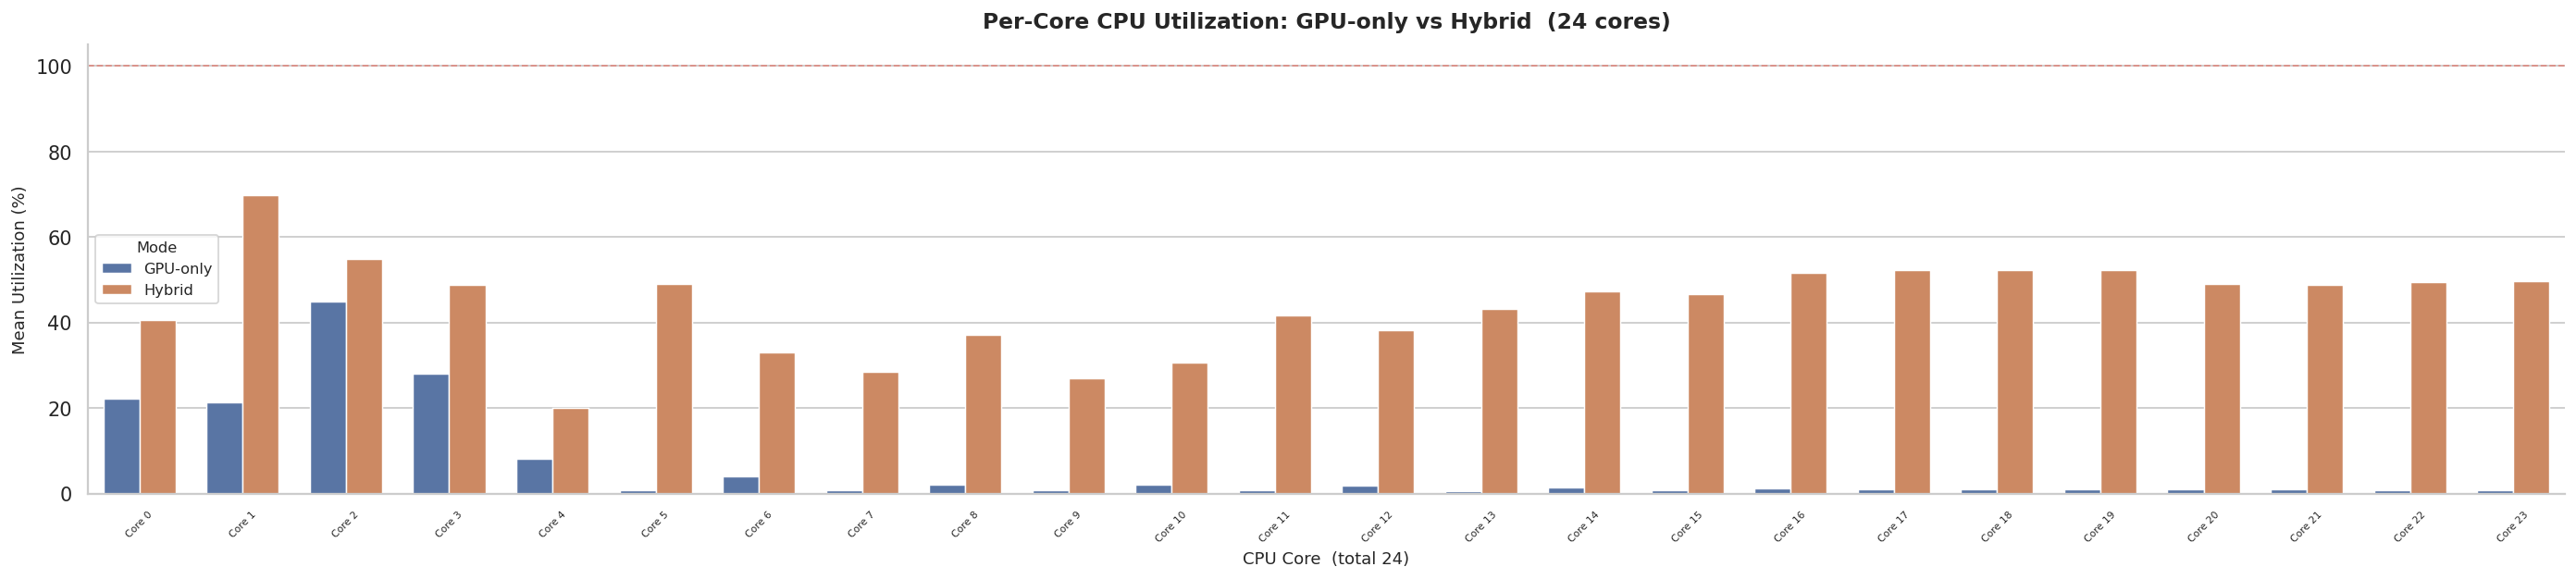

In [91]:
# ============================================================
#  9. Per-Core Utilization Bar / Heatmap — GPU-only vs Hybrid
# ============================================================

if not comparison:
    print("comparison.json not found")
else:
    cu = comparison.get("cpu_utilization", {})
    all_core_keys = sorted(
        [k for k in cu.get("gpu_only", {}).keys()
         if k.startswith("core") and k.endswith("_util_pct")],
        key=lambda k: int(k.replace("core","").replace("_util_pct",""))
    )
    n_cores = len(all_core_keys)

    g_vals = [cu.get("gpu_only",{}).get(k,{}).get("mean", np.nan) for k in all_core_keys]
    h_vals = [cu.get("hybrid",  {}).get(k,{}).get("mean", np.nan) for k in all_core_keys]
    core_labels = [k.replace("_util_pct","").replace("core","C") for k in all_core_keys]

    if n_cores <= 32:
        # ── Grouped bar chart (small core count) ─────────────
        core_bar_rows = []
        for key, g_v, h_v in zip(all_core_keys, g_vals, h_vals):
            cid = key.replace("_util_pct","").replace("core","Core ")
            core_bar_rows += [{"Core":cid,"Mode":"GPU-only","Mean Util (%)":g_v},
                               {"Core":cid,"Mode":"Hybrid",  "Mean Util (%)":h_v}]
        core_bar_df = pd.DataFrame(core_bar_rows)

        fig, ax = plt.subplots(figsize=(max(12, n_cores * 0.9), 5))
        sns.barplot(data=core_bar_df, x="Core", y="Mean Util (%)",
                    hue="Mode", palette=PALETTE, ax=ax,
                    edgecolor="white", linewidth=0.8, width=0.7)
        ax.set_ylim(0, 105)
        ax.axhline(100, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.5)
        ax.set_xlabel(f"CPU Core  (total {n_cores})", fontsize=10)
        ax.set_ylabel("Mean Utilization (%)", fontsize=10)
        ax.set_title(f"Per-Core CPU Utilization: GPU-only vs Hybrid  ({n_cores} cores)",
                     fontsize=13, fontweight="bold", pad=10)
        ax.tick_params(axis="x", rotation=45, labelsize=max(6, 9 - n_cores//8))
        ax.legend(title="Mode", fontsize=9, title_fontsize=9)
        sns.despine()
        plt.tight_layout()
        plt.show()

    else:
        # ── Heatmap layout (large core count: 33+) ────────────
        # Row 0: GPU-only  Row 1: Hybrid  Row 2: Δ (Hybrid - GPU-only)
        g_arr  = np.array(g_vals,                            dtype=float).reshape(1, -1)
        h_arr  = np.array(h_vals,                            dtype=float).reshape(1, -1)
        d_arr  = np.array([h-g for h,g in zip(h_vals,g_vals)], dtype=float).reshape(1, -1)

        # tick positions: label every N cores to avoid clutter
        step = max(1, n_cores // 32)
        tick_pos    = list(range(0, n_cores, step))
        tick_labels = [core_labels[i] for i in tick_pos]

        fig, axes = plt.subplots(3, 1, figsize=(max(16, n_cores * 0.14), 7),
                                 gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.55})
        fig.suptitle(f"Per-Core CPU Utilization  ({n_cores} cores)",
                     fontsize=13, fontweight="bold")

        for ax, data, title, cmap, vmin, vmax in [
            (axes[0], g_arr, "GPU-only  (mean util %)",  "YlGnBu", 0, 100),
            (axes[1], h_arr, "Hybrid    (mean util %)",  "YlOrRd", 0, 100),
            (axes[2], d_arr, "Δ Hybrid − GPU-only (%)", "RdYlGn_r", -50, 50),
        ]:
            im = ax.imshow(data, aspect="auto", cmap=cmap,
                           vmin=vmin, vmax=vmax, interpolation="nearest")
            cb = plt.colorbar(im, ax=ax, orientation="vertical",
                              fraction=0.015, pad=0.01)
            cb.ax.tick_params(labelsize=8)
            cb.set_label("%", fontsize=8)

            ax.set_yticks([])
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha="right")
            ax.set_title(title, fontsize=10, fontweight="semibold", pad=4)

            # annotate mean / max on the right margin
            valid = data[0][~np.isnan(data[0])]
            if len(valid):
                ax.text(1.07, 0.5,
                        f"mean={valid.mean():.1f}\nmax={valid.max():.1f}\nmin={valid.min():.1f}",
                        transform=ax.transAxes, va="center", fontsize=8,
                        color="#444",
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                  edgecolor="#ccc", alpha=0.9))

        plt.tight_layout()
        plt.show()

        # ── Summary bar: socket-level average (group by 56 if 112 cores) ──
        group_size = max(1, n_cores // 4)   # 4 groups for readability
        n_groups   = (n_cores + group_size - 1) // group_size
        grp_labels, grp_g, grp_h = [], [], []
        for gi in range(n_groups):
            s, e = gi * group_size, min((gi+1) * group_size, n_cores)
            grp_labels.append(f"C{s}–{e-1}")
            grp_g.append(np.nanmean(g_vals[s:e]))
            grp_h.append(np.nanmean(h_vals[s:e]))

        grp_rows = []
        for lbl, gv, hv in zip(grp_labels, grp_g, grp_h):
            grp_rows += [{"Group": lbl, "Mode": "GPU-only", "Mean Util (%)": gv},
                         {"Group": lbl, "Mode": "Hybrid",   "Mean Util (%)": hv}]

        fig, ax = plt.subplots(figsize=(max(8, n_groups * 1.4), 4))
        sns.barplot(data=pd.DataFrame(grp_rows), x="Group", y="Mean Util (%)",
                    hue="Mode", palette=PALETTE, ax=ax,
                    edgecolor="white", linewidth=0.8, width=0.65)
        ax.set_ylim(0, 105)
        ax.axhline(100, color="#e74c3c", linewidth=1, linestyle="--", alpha=0.5)
        for patch in ax.patches:
            v = patch.get_height()
            if not np.isnan(v) and v > 0:
                ax.text(patch.get_x() + patch.get_width()/2, v + 1,
                        f"{v:.1f}", ha="center", va="bottom", fontsize=8)
        ax.set_xlabel("Core Group", fontsize=10)
        ax.set_ylabel("Mean Utilization (%)", fontsize=10)
        ax.set_title(f"Core-Group Average  ({group_size} cores/group)",
                     fontsize=11, fontweight="bold")
        ax.legend(title="Mode", fontsize=9)
        sns.despine()
        plt.tight_layout()
        plt.show()


,Avg Power (W),Output TP (tok/s),Efficiency (tok/s/W)
Mode,,,
GPU-only,333.630,9808.183,29.398
Hybrid,314.280,9164.768,29.161


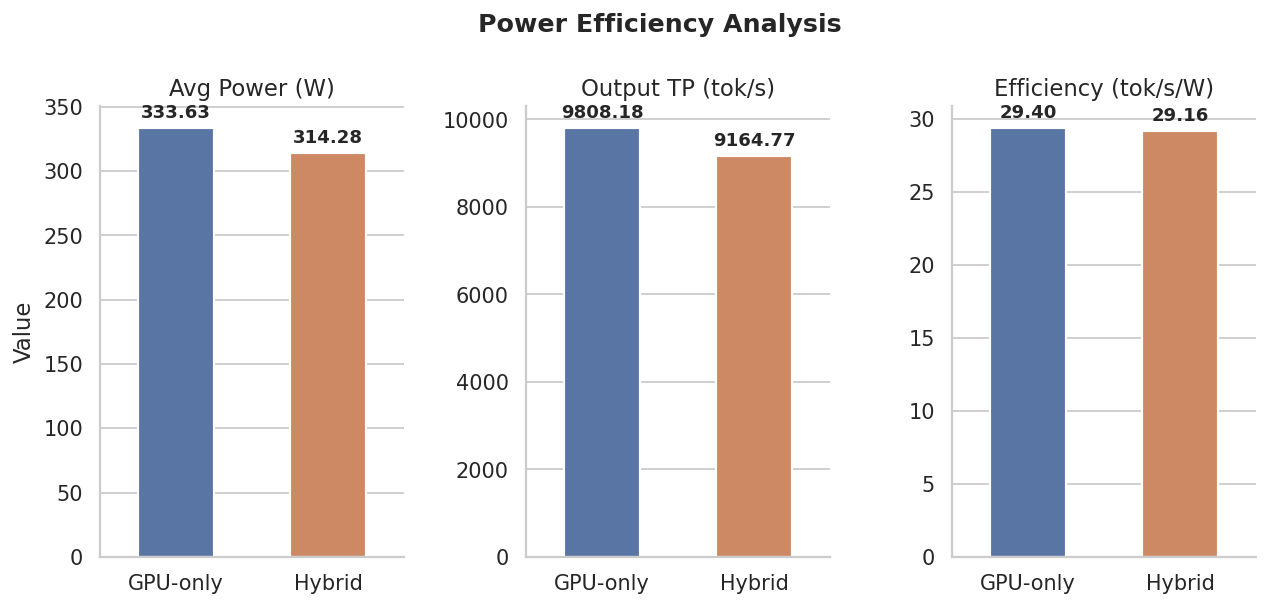

In [92]:
# ============================================================
#  10. Power Efficiency (tok/s per Watt)
# ============================================================

if not comparison:
    print('comparison.json not found')
else:
    gu    = comparison.get('gpu_utilization', {})
    g_pw  = gu.get('gpu_only', {}).get('gpu_avg_power_w', {}).get('mean', np.nan)
    h_pw  = gu.get('hybrid',   {}).get('gpu_avg_power_w', {}).get('mean', np.nan)
    g_out = (gpu_only or {}).get('output_throughput', np.nan)
    h_out = (hybrid   or {}).get('output_throughput', np.nan)
    g_eff = g_out / g_pw if g_pw else np.nan
    h_eff = h_out / h_pw if h_pw else np.nan

    eff_data = pd.DataFrame([
        {'Mode':'GPU-only','Avg Power (W)':g_pw,'Output TP (tok/s)':g_out,'Efficiency (tok/s/W)':g_eff},
        {'Mode':'Hybrid',  'Avg Power (W)':h_pw,'Output TP (tok/s)':h_out,'Efficiency (tok/s/W)':h_eff},
    ])

    display(eff_data.set_index('Mode').style
        .format('{:.3f}', na_rep='-')
        .background_gradient(cmap='Greens', subset=['Efficiency (tok/s/W)'])
        .set_caption('<b style="font-size:14px">Power Efficiency Summary</b>')
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','12px'),('padding','5px 10px')]}]))

    metrics = ['Avg Power (W)', 'Output TP (tok/s)', 'Efficiency (tok/s/W)']
    eff_long = eff_data.melt(id_vars='Mode', value_vars=metrics,
                              var_name='Metric', value_name='Value')

    g = sns.FacetGrid(eff_long, col='Metric', height=4.5, aspect=0.85,
                      sharey=False, gridspec_kws={'wspace': 0.4})

    def draw_eff(data, **kw):
        ax = plt.gca()
        sns.barplot(data=data, x='Mode', y='Value', palette=PALETTE,
                    order=['GPU-only','Hybrid'], ax=ax,
                    edgecolor='white', linewidth=1.2, width=0.5)
        for patch in ax.patches:
            v = patch.get_height()
            if not np.isnan(v) and v > 0:
                ax.text(patch.get_x() + patch.get_width()/2,
                        v * 1.015, f'{v:.2f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    g.map_dataframe(draw_eff)
    g.set_axis_labels('', 'Value')
    g.set_titles(col_template='{col_name}')
    g.figure.suptitle('Power Efficiency Analysis',
                       fontsize=14, fontweight='bold', y=1.04)
    sns.despine()
    plt.show()

In [93]:
# ============================================================
#  11. Raw Data Preview (describe)
# ============================================================

for name, df in [('GPU-only GPU monitor', g_gpu_csv),
                 ('Hybrid GPU monitor',   h_gpu_csv),
                 ('GPU-only CPU monitor', g_cpu_csv),
                 ('Hybrid CPU monitor',   h_cpu_csv)]:
    if df is None: continue
    print(f'\n{name}: {len(df)} rows × {len(df.columns)} cols')
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    display(df[numeric_cols].describe().T
        .style.format('{:.2f}', na_rep='-')
        .background_gradient(cmap='coolwarm', subset=['mean'], axis=0)
        .set_table_styles([{'selector':'th',
            'props':[('background-color','#2d4a7a'),('color','white'),
                     ('font-size','11px'),('padding','4px 8px')]}])
        .set_caption(f'<b>{name} — describe()</b>'))


GPU-only GPU monitor: 128 rows × 10 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,128.00,65.71,37.86,0.90,33.30,65.71,98.11,130.52
gpu0_util_pct,128.00,74.67,37.59,0.00,92.00,93.00,94.00,100.00
gpu0_mem_util_pct,128.00,38.48,20.70,0.00,36.75,46.00,51.00,81.00
gpu0_mem_used_mb,128.00,20012.77,7037.33,38.00,22680.00,22680.00,22680.00,22680.00
gpu0_power_w,128.00,333.63,109.12,46.35,386.12,387.54,388.15,389.69
gpu0_temp_c,128.00,60.09,6.56,44.00,59.75,63.00,65.00,66.00
gpu_avg_util_pct,128.00,74.67,37.59,0.00,92.00,93.00,94.00,100.00
gpu_avg_mem_util_pct,128.00,38.48,20.70,0.00,36.75,46.00,51.00,81.00
gpu_avg_power_w,128.00,333.63,109.12,46.35,386.12,387.54,388.15,389.69



Hybrid GPU monitor: 147 rows × 10 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,147.00,75.54,43.56,0.90,38.16,75.53,112.92,150.17
gpu0_util_pct,147.00,65.37,38.66,0.00,26.50,82.00,93.00,100.00
gpu0_mem_util_pct,147.00,33.79,21.32,0.00,10.00,42.00,48.00,81.00
gpu0_mem_used_mb,147.00,20238.41,6740.79,38.00,22680.00,22680.00,22680.00,22680.00
gpu0_power_w,147.00,314.28,110.84,49.56,246.13,369.02,387.46,389.30
gpu0_temp_c,147.00,60.18,5.85,47.00,55.00,63.00,65.00,66.00
gpu_avg_util_pct,147.00,65.37,38.66,0.00,26.50,82.00,93.00,100.00
gpu_avg_mem_util_pct,147.00,33.79,21.32,0.00,10.00,42.00,48.00,81.00
gpu_avg_power_w,147.00,314.28,110.84,49.56,246.13,369.02,387.46,389.30



GPU-only CPU monitor: 128 rows × 29 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,128.00,65.71,37.86,0.90,33.30,65.71,98.11,130.52
core0_util_pct,128.00,22.11,23.71,0.00,5.07,11.80,30.88,100.00
core1_util_pct,128.00,21.31,30.38,0.00,1.00,8.90,21.80,100.00
core2_util_pct,128.00,44.90,39.37,0.00,6.65,35.45,91.15,100.00
core3_util_pct,128.00,27.94,39.71,0.00,0.00,2.90,44.53,100.00
core4_util_pct,128.00,8.21,5.39,0.00,3.00,8.80,12.60,22.80
core5_util_pct,128.00,0.75,2.20,0.00,0.00,0.00,0.00,8.70
core6_util_pct,128.00,3.98,3.16,0.00,1.98,3.00,5.80,12.90
core7_util_pct,128.00,0.71,2.25,0.00,0.00,0.00,0.00,11.70
core8_util_pct,128.00,2.00,2.72,0.00,0.00,1.00,2.00,14.60



Hybrid CPU monitor: 147 rows × 29 cols


,count,mean,std,min,25%,50%,75%,max
elapsed_s,147.00,75.54,43.56,0.90,38.16,75.53,112.92,150.17
core0_util_pct,147.00,40.55,30.09,0.00,16.65,33.70,55.40,100.00
core1_util_pct,147.00,69.80,31.82,0.00,51.00,77.50,100.00,100.00
core2_util_pct,147.00,54.82,37.50,0.00,21.65,55.30,99.00,100.00
core3_util_pct,147.00,48.85,38.86,0.00,7.80,47.60,89.65,100.00
core4_util_pct,147.00,19.96,24.88,0.00,2.00,5.90,35.75,100.00
core5_util_pct,147.00,48.99,43.05,0.00,5.90,50.00,100.00,100.00
core6_util_pct,147.00,32.92,39.04,0.00,1.95,9.80,65.05,100.00
core7_util_pct,147.00,28.54,37.43,0.00,0.00,7.80,47.00,100.00
core8_util_pct,147.00,37.13,39.31,0.00,3.45,16.00,76.00,100.00
